In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [2]:
dataset_path = "../dataset/PlantVillage"

train_path = os.path.join(dataset_path, "train")
val_path = os.path.join(dataset_path, "val")

print("Train path:", train_path)
print("Val path:", val_path)

Train path: ../dataset/PlantVillage\train
Val path: ../dataset/PlantVillage\val


In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 38

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)

Image size: (224, 224)
Batch size: 32
Number of classes: 38


In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.


In [5]:
class_names = train_ds.class_names

print("Jumlah kelas:", len(class_names))

for i, class_name in enumerate(class_names):
    print(i, class_name)

Jumlah kelas: 38
0 Apple___Apple_scab
1 Apple___Black_rot
2 Apple___Cedar_apple_rust
3 Apple___healthy
4 Blueberry___healthy
5 Cherry_(including_sour)___Powdery_mildew
6 Cherry_(including_sour)___healthy
7 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 Corn_(maize)___Common_rust_
9 Corn_(maize)___Northern_Leaf_Blight
10 Corn_(maize)___healthy
11 Grape___Black_rot
12 Grape___Esca_(Black_Measles)
13 Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 Grape___healthy
15 Orange___Haunglongbing_(Citrus_greening)
16 Peach___Bacterial_spot
17 Peach___healthy
18 Pepper,_bell___Bacterial_spot
19 Pepper,_bell___healthy
20 Potato___Early_blight
21 Potato___Late_blight
22 Potato___healthy
23 Raspberry___healthy
24 Soybean___healthy
25 Squash___Powdery_mildew
26 Strawberry___Leaf_scorch
27 Strawberry___healthy
28 Tomato___Bacterial_spot
29 Tomato___Early_blight
30 Tomato___Late_blight
31 Tomato___Leaf_Mold
32 Tomato___Septoria_leaf_spot
33 Tomato___Spider_mites Two-spotted_spider_mite
34 Tomato___T

In [6]:
for images, labels in train_ds.take(1):
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)
    print("Pixel minimum:", tf.reduce_min(images).numpy())
    print("Pixel maximum:", tf.reduce_max(images).numpy())

Image shape: (32, 224, 224, 3)
Label shape: (32,)
Pixel minimum: 0.0
Pixel maximum: 255.0


In [7]:
train_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_path, class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    train_counts[class_name] = len(images)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=np.repeat(
        np.arange(NUM_CLASSES),
        [train_counts[class_name] for class_name in class_names]
    )
)

class_weights = {
    i: weight
    for i, weight in enumerate(class_weights_array)
}

print("Class weights:")
for i, weight in class_weights.items():
    print(f"{i:2d} | {class_names[i]:55s} | {weight:.4f}")

Class weights:
 0 | Apple___Apple_scab                                      | 2.2684
 1 | Apple___Black_rot                                       | 2.3050
 2 | Apple___Cedar_apple_rust                                | 5.1967
 3 | Apple___healthy                                         | 0.8687
 4 | Blueberry___healthy                                     | 0.9511
 5 | Cherry_(including_sour)___Powdery_mildew                | 1.3578
 6 | Cherry_(including_sour)___healthy                       | 1.6714
 7 | Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      | 2.7884
 8 | Corn_(maize)___Common_rust_                             | 1.1996
 9 | Corn_(maize)___Northern_Leaf_Blight                     | 1.4508
10 | Corn_(maize)___healthy                                  | 1.2306
11 | Grape___Black_rot                                       | 1.2111
12 | Grape___Esca_(Black_Measles)                            | 1.0328
13 | Grape___Leaf_blight_(Isariopsis_Leaf_Spot)              | 1.3278
14 | 

In [8]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

In [9]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

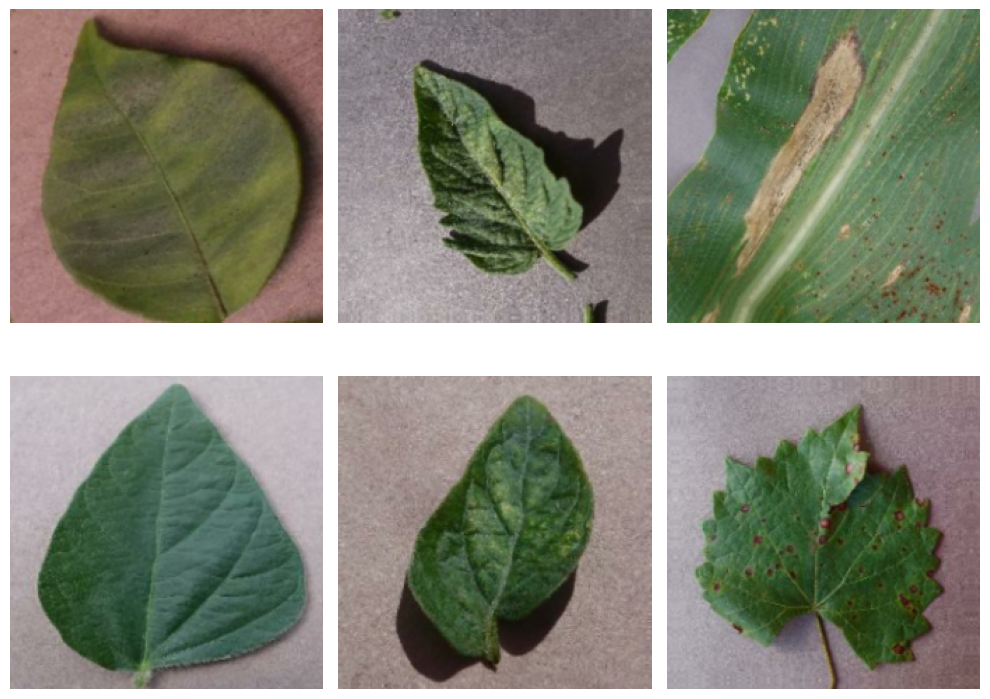

In [10]:
plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):
    augmented_images = data_augmentation(images)

    for i in range(6):
        plt.subplot(2, 3, i + 1)
        plt.imshow(
            tf.cast(
                tf.clip_by_value(augmented_images[i], 0, 255),
                tf.uint8
            )
        )
        plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print("Dataset siap untuk training.")

Dataset siap untuk training.


In [12]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("MobileNetV2 berhasil dimuat.")
print("Trainable:", base_model.trainable)

MobileNetV2 berhasil dimuat.
Trainable: False


In [13]:
inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = keras.Model(
    inputs=inputs,
    outputs=outputs
)

In [14]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model berhasil di-compile.")

Model berhasil di-compile.
